In [10]:
import sys
sys.path.append('..')
from data_loader import get_data
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay


X_train, X_val, X_test, y_train, y_val, y_test = get_data()
print('X_tr:', X_train.shape, 'X_te:', X_test.shape, 'X_va:', X_val.shape)

X_tr: (48000, 784) X_te: (10000, 784) X_va: (12000, 784)


In [11]:
from cross_val_data import cross_validation

tr_fold, val_fold = cross_validation()
print('tr_fold:', len(tr_fold), 'val_fold:', len(val_fold))
print('tr_fold shape:', tr_fold[0][0].shape)
print('val_fold shape:', val_fold[0][0].shape)

tr_fold: 5 val_fold: 5
tr_fold shape: (48000, 784)
val_fold shape: (12000, 784)


In [ ]:
results = {}  # key: (weight, k), value: avg acc across 5 folds

for weight in ['uniform', 'distance']:
    for k in [1, 3, 5, 7, 10, 20, 50]:
        
        fold_accs = []
        for i in range(5):
            X_tr, y_tr = tr_fold[i]
            X_val, y_val = val_fold[i]
            
            model = KNeighborsClassifier(n_neighbors=k, weights=weight)
            model.fit(X_tr, y_tr)
            acc = accuracy_score(y_val, model.predict(X_val))
            fold_accs.append(acc)
        
        results[(weight, k)] = np.mean(fold_accs)

print(f"{'k':<6} {'uniform':<12} {'distance':<12}")
for k in [1, 3, 5, 7, 10, 20, 50]:
    u = results[('uniform', k)]
    d = results[('distance', k)]
    print(f"{k:<6} {u:<12.4f} {d:<12.4f}")

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
final_model.fit(X_train_full, y_train_full)
print(accuracy_score(y_test, final_model.predict(X_test)))

0.8485


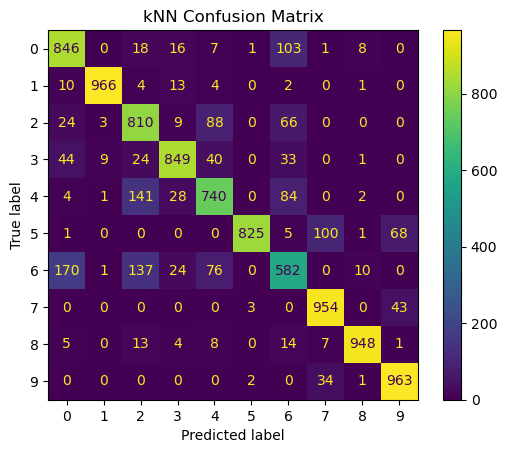

In [ ]:
y_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('kNN Confusion Matrix')
plt.savefig('knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()